<a href="https://colab.research.google.com/github/mustaphaelansary7-rgb/mostafa-data-analysis/blob/main/Mostafa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import numpy as np
import pandas as pd
import warnings

#ploting libraries
import matplotlib.pyplot as plt
import seaborn as sns

#relevant ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score

#ML models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#default theme
sns.set(context='notebook' , style='darkgrid' , palette='deep' , font='sans-serif' , font_scale=1)

#warning hadle
warnings.filterwarnings("ignore")

In [52]:
#path for the training set
tr_path = "/content/train_data.csv"
#path for the testing set
te_path = "/content/test_data.csv"

In [53]:
# read in csv file as a DataFrame
tr_df = pd.read_csv(tr_path)

In [54]:
# explore the first 5 rows
tr_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [55]:
 # read in csv file as a DataFrame
te_df = pd.read_csv(te_path)

In [56]:
# explore the first 5 rows
te_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [59]:
print(f"training set (row, col): {tr_df.shape}\n\ntesting set (row, col): {te_df.shape}")

training set (row, col): (614, 13)

testing set (row, col): (367, 12)


In [60]:
tr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [61]:
#summary statistics
tr_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [62]:
#the Id column is not needed, let's drop it for both test and train datasets
tr_df.drop('Loan_ID',axis=1,inplace=True)
te_df.drop('Loan_ID',axis=1,inplace=True)

In [63]:
#checking the new shapes
print(f"training set (row, col): {tr_df.shape}\n\ntesting set (row, col): {te_df.shape}")

training set (row, col): (614, 12)

testing set (row, col): (367, 11)


In [64]:
 #missing values in decsending order
tr_df.isnull().sum().sort_values(ascending=False)

,0
Credit_History,50
Self_Employed,32
LoanAmount,22
Dependents,15
Loan_Amount_Term,14
Gender,13
Married,3
Education,0
CoapplicantIncome,0
ApplicantIncome,0


In [65]:
 #filling the missing data
print("Before filling missing values\n\n","#"*50,"\n")
null_cols = ['Credit_History', 'Self_Employed', 'LoanAmount','Dependents', 'Loan_Amount_Term', ]
for col in null_cols:
    print(f"{col}:\n{tr_df[col].value_counts()}\n","-"*50)
    tr_df[col] = tr_df[col].fillna(
    tr_df[col].dropna().mode().values[0] )
tr_df.isnull().sum().sort_values(ascending=False)
print("After filling missing values\n\n","#"*50,"\n")
for col in null_cols:
    print(f"\n{col}:\n{tr_df[col].value_counts()}\n","-"*50)

Before filling missing values

 ################################################## 

Credit_History:
Credit_History
1.0    475
0.0     89
Name: count, dtype: int64
 --------------------------------------------------
Self_Employed:
Self_Employed
No     500
Yes     82
Name: count, dtype: int64
 --------------------------------------------------
LoanAmount:
LoanAmount
120.0    20
110.0    17
100.0    15
187.0    12
160.0    12
         ..
292.0     1
142.0     1
350.0     1
496.0     1
253.0     1
Name: count, Length: 203, dtype: int64
 --------------------------------------------------
Dependents:
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64
 --------------------------------------------------
Loan_Amount_Term:
Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64
 --------------------------------------------------
After filling missing val

In [66]:
#list of all the columns.columns
#Cols = tr_df.tolist()
#list of all the numeric columns
num = tr_df.select_dtypes('number').columns.to_list()
#list of all the categoric columns
cat = tr_df.select_dtypes('object').columns.to_list()
#numeric df
loan_num =  tr_df[num]
#categoric df
loan_cat = tr_df[cat]

Loan_Status
Y    422
N    192
Name: count, dtype: int64


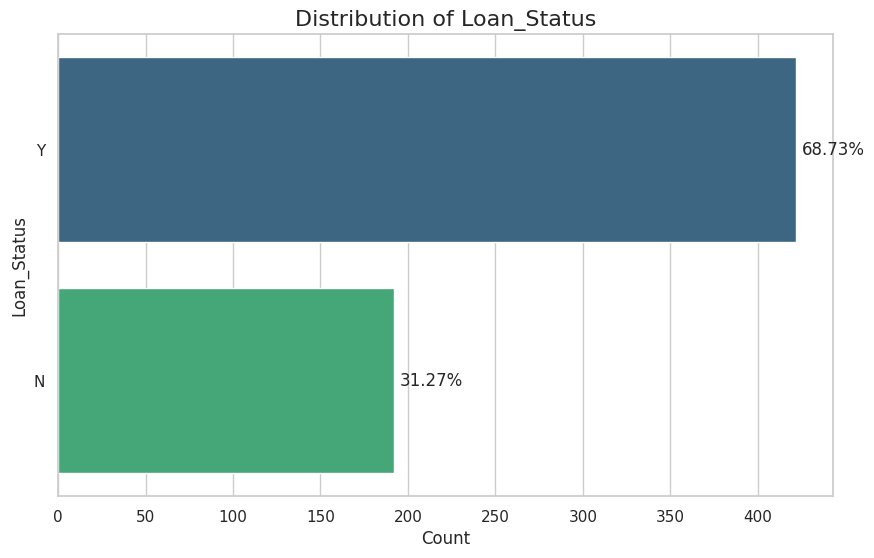

In [67]:
print(tr_df[cat[-1]].value_counts())

total = float(len(tr_df[cat[-1]]))
plt.figure(figsize=(10, 6)) # Adjust figure size for horizontal plot
sns.set(style="whitegrid")

# Create a horizontal countplot with data directly from tr_df
ax = sns.countplot(y=cat[-1], data=tr_df, palette='viridis', order=tr_df[cat[-1]].value_counts().index)

plt.title(f'Distribution of {cat[-1]}', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel(cat[-1], fontsize=12)

# Annotate bars with percentages
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 3, p.get_y() + p.get_height()/2,
             '{:1.2f}%'.format(100 * width / total),
             ha="left", va="center")

plt.show()

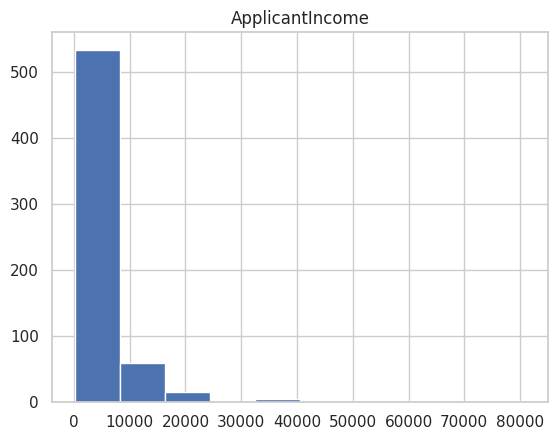

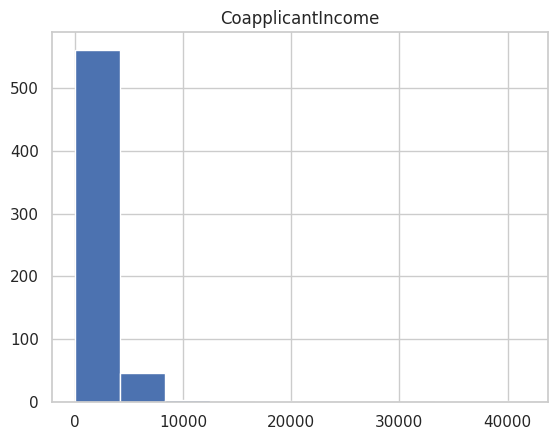

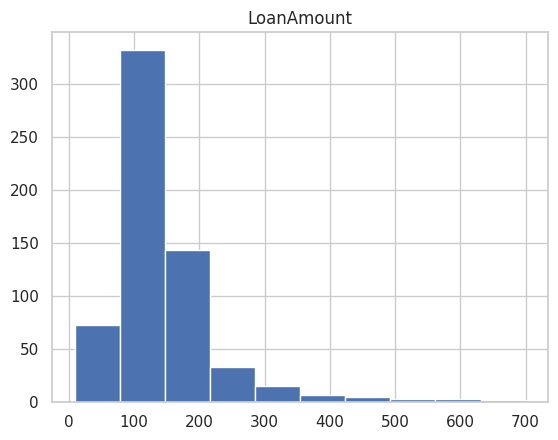

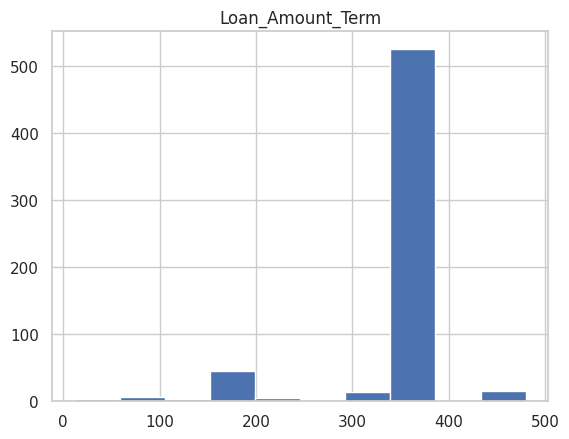

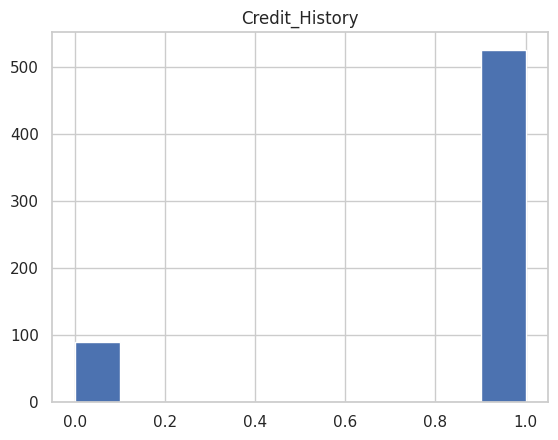

In [68]:
for i in loan_num:
    plt.hist(loan_num[i])
    plt.title(i)
    plt.show()


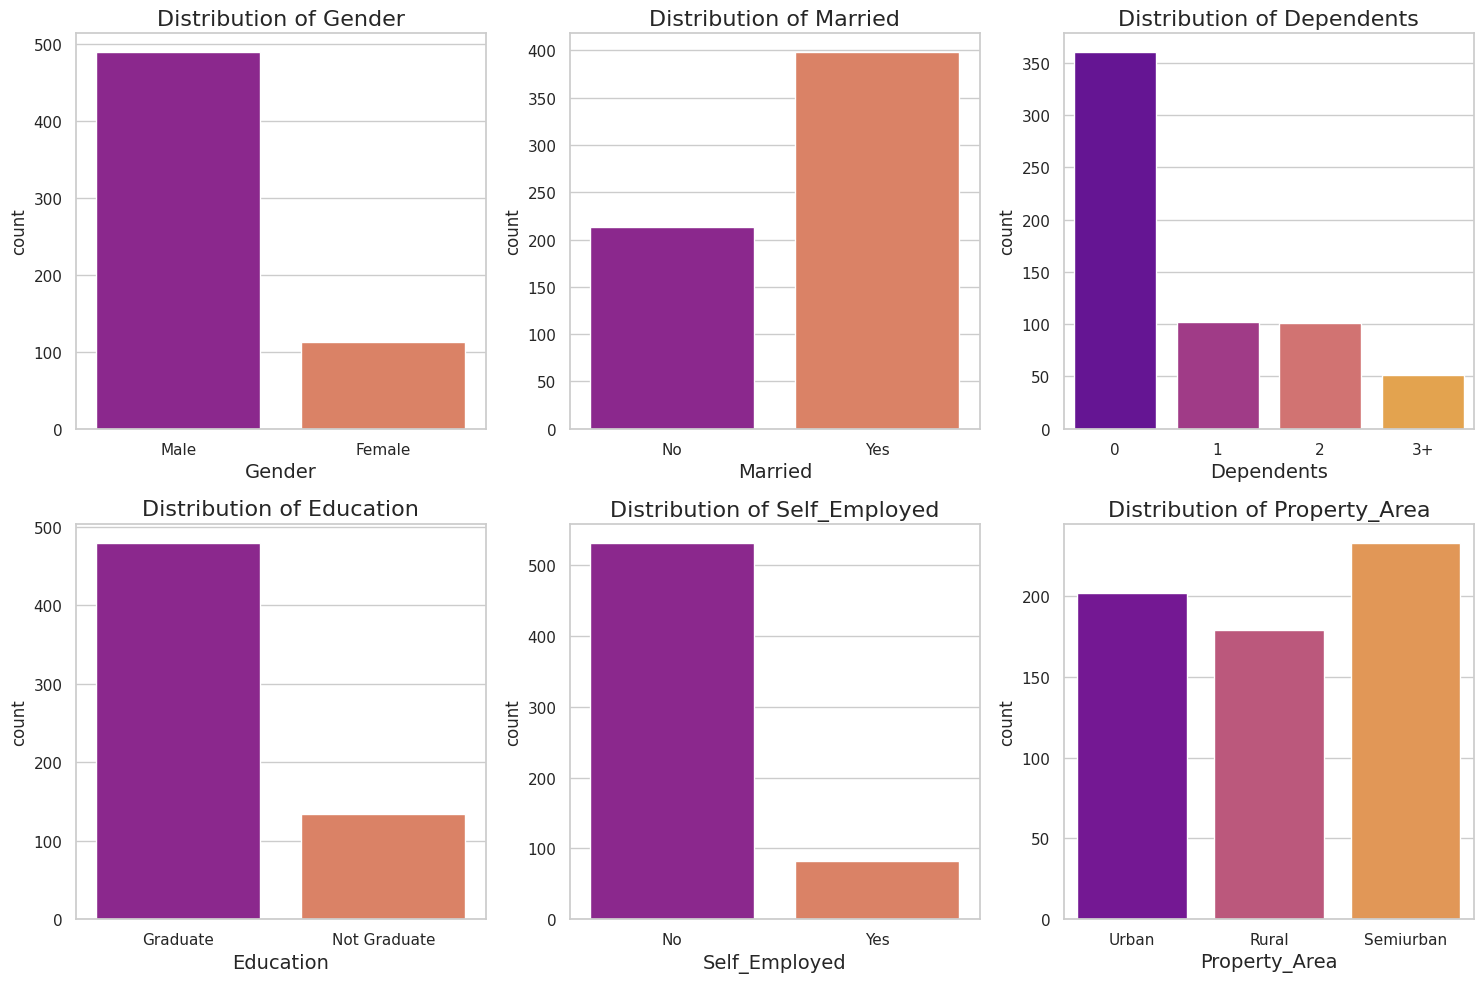

In [69]:
plt.figure(figsize=(15,10))
for idx, col in enumerate(cat[:-1]): # Iterate through categorical columns except the last one
    plt.subplot(2,3,idx+1) # Create a 2x3 grid of subplots
    sns.countplot(x=col , data=tr_df ,palette='plasma') # Removed hue='Loan_Status'
    plt.xlabel(col, fontsize=14)
    plt.title(f'Distribution of {col}', fontsize=16)
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [70]:
#converting categorical values to numbers
to_numeric = {'Male': 1, 'Female': 2,
'Yes': 1, 'No': 2,
'Graduate': 1, 'Not Graduate': 2,
'Urban': 3, 'Semiurban': 2,'Rural': 1,
'Y': 1, 'N': 0,
'3+': 3}

In [71]:
# adding the new numeric values from the to_numeric variable to both datasets
tr_df = tr_df.applymap(lambda lable: to_numeric.get(lable) if lable in to_numeric else lable)
te_df = te_df.applymap(lambda lable: to_numeric.get(lable) if lable in to_numeric else lable)
# convertind the Dependents column
Dependents_ = pd.to_numeric(tr_df.Dependents)
Dependents__ = pd.to_numeric(te_df.Dependents)
# dropping the previous Dependents column
tr_df.drop(['Dependents'], axis = 1, inplace = True)
te_df.drop(['Dependents'], axis = 1, inplace = True)
# concatination of the new Dependents column with both datasets
tr_df = pd.concat([tr_df, Dependents_], axis = 1)
te_df = pd.concat([te_df, Dependents__], axis = 1)
# checking the our manipulated dataset for validation
print(f"training set (row, col): {tr_df.shape}\n\ntesting set (row, col): {te_df.shape}\n")
print(tr_df.info(), "\n\n", te_df.info())

training set (row, col): (614, 12)

testing set (row, col): (367, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    float64
 1   Married            611 non-null    float64
 2   Education          614 non-null    int64  
 3   Self_Employed      614 non-null    int64  
 4   ApplicantIncome    614 non-null    int64  
 5   CoapplicantIncome  614 non-null    float64
 6   LoanAmount         614 non-null    float64
 7   Loan_Amount_Term   614 non-null    float64
 8   Credit_History     614 non-null    float64
 9   Property_Area      614 non-null    int64  
 10  Loan_Status        614 non-null    int64  
 11  Dependents         614 non-null    int64  
dtypes: float64(6), int64(6)
memory usage: 57.7 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 11 column

<Axes: >

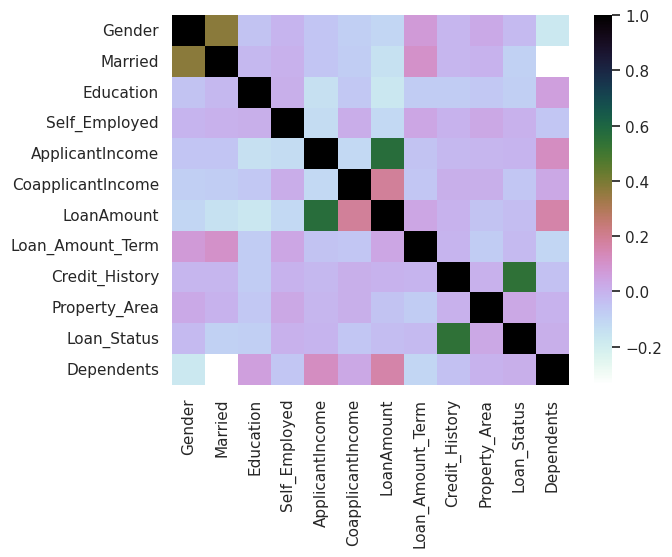

In [72]:
#plotting the correlation matrix
sns.heatmap(tr_df.corr() ,cmap='cubehelix_r')


In [74]:
#correlation table
corr = tr_df.corr()
corr.style.background_gradient(cmap='coolwarm').format(precision=2)

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Dependents
Gender,1.00,0.37,-0.05,-0.01,-0.05,-0.08,-0.10,0.07,-0.01,0.02,-0.02,-0.17
Married,0.37,1.00,-0.01,0.01,-0.05,-0.08,-0.15,0.10,-0.01,-0.00,-0.09,-0.34
Education,-0.05,-0.01,1.00,0.01,-0.14,-0.06,-0.17,-0.07,-0.07,-0.07,-0.09,0.06
Self_Employed,-0.01,0.01,0.01,1.00,-0.13,0.02,-0.11,0.03,0.00,0.03,0.00,-0.06
ApplicantIncome,-0.05,-0.05,-0.14,-0.13,1.00,-0.12,0.56,-0.05,-0.02,-0.01,-0.00,0.12
CoapplicantIncome,-0.08,-0.08,-0.06,0.02,-0.12,1.00,0.19,-0.06,0.01,0.01,-0.06,0.03
LoanAmount,-0.10,-0.15,-0.17,-0.11,0.56,0.19,1.00,0.04,-0.00,-0.05,-0.03,0.16
Loan_Amount_Term,0.07,0.10,-0.07,0.03,-0.05,-0.06,0.04,1.00,-0.00,-0.08,-0.02,-0.10
Credit_History,-0.01,-0.01,-0.07,0.00,-0.02,0.01,-0.00,-0.00,1.00,0.00,0.54,-0.04
Property_Area,0.02,-0.00,-0.07,0.03,-0.01,0.01,-0.05,-0.08,0.00,1.00,0.03,-0.00


In [75]:
y = tr_df['Loan_Status']
X = tr_df.drop('Loan_Status', axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [76]:
DT = DecisionTreeClassifier()
DT.fit(X_train, y_train)
y_predict = DT.predict(X_test)
#  prediction Summary by species
print(classification_report(y_test, y_predict))
# Accuracy score
DT_SC = accuracy_score(y_predict,y_test)
print(f"{round(DT_SC*100,2)}% Accurate")

              precision    recall  f1-score   support

           0       0.45      0.49      0.47        51
           1       0.80      0.77      0.78       134

    accuracy                           0.69       185
   macro avg       0.62      0.63      0.63       185
weighted avg       0.70      0.69      0.70       185

69.19% Accurate


In [77]:
Decision_Tree=pd.DataFrame({'y_test':y_test,'prediction':y_predict})
Decision_Tree.to_csv("Dection Tree.csv")

In [78]:
RF = RandomForestClassifier()
RF.fit(X_train, y_train)
y_predict = RF.predict(X_test)
#  prediction Summary by species
print(classification_report(y_test, y_predict))
# Accuracy score
RF_SC = accuracy_score(y_predict,y_test)
print(f"{round(RF_SC*100,2)}% Accurate")


              precision    recall  f1-score   support

           0       0.78      0.41      0.54        51
           1       0.81      0.96      0.88       134

    accuracy                           0.81       185
   macro avg       0.79      0.68      0.71       185
weighted avg       0.80      0.81      0.78       185

80.54% Accurate


In [79]:
XGBoost=pd.DataFrame({'y_test':y_test,'prediction':y_predict})
XGBoost.to_csv("XGBoost.csv")

In [81]:
# Fill remaining missing values in tr_df for 'Gender' and 'Married' using mode
for col in ['Gender', 'Married']:
    if tr_df[col].isnull().any():
        mode_val = tr_df[col].mode()[0]
        tr_df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

print("\nNull values in tr_df after final imputation:")
print(tr_df.isnull().sum().sort_values(ascending=False))

# Redefine X and y from the cleaned tr_df
y = tr_df['Loan_Status']
X = tr_df.drop('Loan_Status', axis=1)

# Re-split the data after cleaning
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Now, re-run the Logistic Regression model
LR = LogisticRegression()
LR.fit(X_train, y_train)
y_predict = LR.predict(X_test)

# Prediction Summary
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_predict))

# Accuracy score
LR_SC = accuracy_score(y_predict, y_test)
print(f'Logistic Regression accuracy is: {round(LR_SC*100,2)}%')

# Optional: Save predictions to CSV if needed
Logistic_Regression_DF = pd.DataFrame({'y_test': y_test, 'prediction': y_predict})
Logistic_Regression_DF.to_csv("Logistic_Regression.csv")
print("\nLogistic Regression predictions saved to Logistic_Regression.csv")

Filled missing values in 'Gender' with mode: 1.0
Filled missing values in 'Married' with mode: 1.0

Null values in tr_df after final imputation:
Gender               0
Married              0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Dependents           0
dtype: int64

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.43      0.59        51
           1       0.82      0.99      0.89       134

    accuracy                           0.83       185
   macro avg       0.87      0.71      0.74       185
weighted avg       0.85      0.83      0.81       185

Logistic Regression accuracy is: 83.24%

Logistic Regression predictions saved to Logistic_Regression.csv


In [82]:
Logistic_Regression=pd.DataFrame({'y_test':y_test,'prediction':y_predict})
Logistic_Regression.to_csv("Logistic Regression.csv")

In [84]:
# Train XGBoost Classifier and calculate its score
XGB = XGBClassifier()
XGB.fit(X_train, y_train)
y_predict_xgb = XGB.predict(X_test)
# Prediction Summary by species
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_predict_xgb))
# Accuracy score
XGB_SC = accuracy_score(y_predict_xgb, y_test)
print(f'XGBoost accuracy is: {round(XGB_SC*100,2)}%')

# Save predictions to CSV (correcting the previous `y_predict` usage)
XGBoost_df = pd.DataFrame({'y_test':y_test,'prediction':y_predict_xgb})
XGBoost_df.to_csv("XGBoost.csv")
print("\nXGBoost predictions saved to XGBoost.csv")


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.53      0.61        51
           1       0.84      0.93      0.88       134

    accuracy                           0.82       185
   macro avg       0.78      0.73      0.75       185
weighted avg       0.81      0.82      0.81       185

XGBoost accuracy is: 81.62%

XGBoost predictions saved to XGBoost.csv


In [85]:
score = [DT_SC,RF_SC,XGB_SC,LR_SC]
Models = pd.DataFrame({
'n_neighbors': ["Decision Tree","Random Forest","XGBoost", "Logistic Regression"],
'Score': score})
Models.sort_values(by='Score', ascending=False)

,n_neighbors,Score
3,Logistic Regression,0.832432
2,XGBoost,0.816216
1,Random Forest,0.805405
0,Decision Tree,0.691892
